# Hard probes of heavy ion collisions with ***ATLAS*** Open Data
A key result the ATLAS heavy ion program was the observation of a centrality dependent asymmetry in jets produced in hard-scattering processes, illustrating the energy loss of these jets by traversal through the dense, coloured medium of the quark gluon plasma (QGP). This was [first observed in the ATLAS detector](https://arxiv.org/abs/1011.6182) with data from Run 1 $\mathrm{PbPb}$ collisions. This notebook will recreate that result with Run 2 data, using the heavy ion hard probes release of ATLAS Open Data (HIONHPOD), which includes all good collision data in this period, as well as dijet Monte Carlo (MC) samples.

## Setup

We begin by setting up our environment to stream these data from the CERN Open Data portal using the tailor-made `atlasopenmagic` module.

In [1]:
# # Install atlasopenmagic. 
# # --user is only required on SWAN, but shouldn't cause issues elsewhere.
# %pip install --user atlasopenmagic

In [2]:
# # SWAN may not include the local package installation in the PYTHONPATH, so we work around this.
# # Again, this shouldn't cause issues elsewhere.
# import sys
# import os
# sys.path += [ f'{os.environ["HOME"]}/.local/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages' ]

# # We can now safely import atlasopenmagic and install its recommended packages
# import atlasopenmagic
# atlasopenmagic.install_from_environment()

We now import some standard HEP data analysis packages to read and manipulate our data, as well as some quality-of-life modules, variables, and methods.

In [3]:
# Pythonic ROOT file reading
import uproot
# Analysis
import awkward as ak
import numpy as np
# Data visualisation / plotting
import matplotlib.pyplot as plt
import matplotlib
# Multiprocessing
from multiprocessing import Pool
# Read/write JSON
import json
# Progress bars
from tqdm import tqdm
# Typing
from typing import Callable
# Run-time stats
import time

MeVtoGeV = 1e-3
pi = np.pi
with open("dijet_asymmetry.json") as f:
    config = json.load(f)
    hist_config = config["hist_config"]
    formatting  = config["formatting"]
    mc_metadata = config["mc_metadata"]
    del config

# Get the number of entries in a jagged awkward array
def get_entries(array:ak.Array):
    return ak.sum(ak.num(array))

Finally, some options and functions for pretty plotting...

In [4]:
# Change our plotting font to sans serif, for aesthetics!
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica","Arial","Nimbus Sans","DejaVu Sans"],
    "svg.fonttype": "path"
})

# Inward facing axis tacks
def inner_ticks(ax:matplotlib.axes.Axes):
    ax.tick_params(direction="in",which="both",top=True,right=True)

# Plot an ATLAS Open Data label on a pair of axes
def atlas_label(ax:matplotlib.axes.Axes,loc="upper right",text="Open Data",fontsize=16,pos_ovr=None,msg=r"PbPb $\sqrt{s}=5.02\ \mathrm{TeV}$",mc=False,msg_offset=.05,extra_msg=[]):
    locs = {
        "upper left" : (.04, .88),
        "upper right": (.96, .88),
    }
    if (pos_ovr is not None) and isinstance(pos_ovr,tuple):
        pos = pos_ovr 
    else: pos = locs[loc]
    # Match text alignment with legend position
    align = ("left","right","center"); ha = "left"
    for a in align:
        if a in loc: ha = a
    ax.text(
        *pos,r"$\mathbfit{ATLAS}$ "+text,
        transform=ax.transAxes,fontsize=fontsize,ha=ha,va="bottom"
    )
    if msg:
        if mc: msg = r"PbPb MC $\sqrt{s}=5.02\ \mathrm{TeV}$"
        ax.text(
            pos[0], pos[1]-msg_offset, msg,
            transform=ax.transAxes, fontsize=fontsize*.75, ha=ha, va="bottom"
        )
    if extra_msg:
        for i,string in enumerate(extra_msg):
            ax.text(
                pos[0], pos[1]-(i+2)*msg_offset, string,
                transform=ax.transAxes, fontsize=fontsize*.75, ha=ha, va="bottom"
            )

## Kinematic selections and centrality binning
Following the example of the Run 1 paper, we define kinematic selections on the jets in our events, which we will gather later, using `awkward` array masking. We apply the following selections in order:
- $N_\mathrm{jets}\geq 2$
- $E_\mathrm{T1}> 100\ \mathrm{GeV}$
- $|\Delta\phi| > \pi/2$ (jets in opposite hemisphere to the leading jet)
- $E_\mathrm{T2}> 25\ \mathrm{GeV}$
- $|\eta_1| < 2.8$
- $|\eta_2| < 2.8$

Note that hemisphere cuts remove objects and not events; except in the case that an event is left with less than two jets. Because the transverse energy is not stored in the HIONHPOD format, we must reconstruct it using the variables available, with
\begin{equation*}
E_\mathrm{T} = \frac{E}{\cosh\eta} = \sqrt{\frac{p^2+m^2}{\cosh^2\eta}} = \sqrt{p_\mathrm{T}^2+\frac{m^2}{\cosh^2\eta}}.
\end{equation*}
An issue also arises when applying cuts on $\Delta\phi$. Because we define $\phi\in[-\pi,\pi]$, two jets at $\phi_1=\pi-\delta$ and $\phi_2=-\pi+\delta$ will have $|\Delta\phi|\sim2\pi$ and therefore pass the angular seperation selection, despite being physically nearby. We therefore wrap our values of $\phi$ to account for this.

Whilst the Run 1 paper does not make an $\eta$ selection on the second jet, we apply one here for sanity, excluding jets in the FCal range ($3.2<|\eta|<4.9$) that will contribute to centrality determination. The paper claims that such selections did not affect final distributions.

In [5]:
# N_jets < 2
def cut_n_jets(jets:ak.Array,N=2)->ak.Array:
    return jets[ak.num(jets) >= N]

# Reconstruct the jet transverse energy
def calculate_jet_et(jets:ak.Array)->ak.Array:
    jets["et"] = np.sqrt(jets["pt"]*jets["pt"] + jets["m"]*jets["m"]/(np.cosh(jets["eta"])*np.cosh(jets["eta"])))
    return jets

# Leading transverse energy ET1 > 100 GeV
def cut_leading_et(jets:ak.Array,leading=100)->ak.Array:
    jets = calculate_jet_et(jets)
    # Sort jets by ET
    jets = jets[ak.argsort(jets["et"],axis=1,ascending=False)]
    return jets[jets["et"][:,0]*MeVtoGeV > leading]

# Calculate wrapped Δφ
def deltaphi(phi1,phi2)->np.array:
    return np.abs((phi2 - phi1 + pi) % (2*pi) - pi)
# Apply Δφ cut for jets in opposite hemispheres
def cut_deltaphi(jets:ak.Array,min_delta=pi*.5):
    # Calculate the wrapped Δφ between the leading jet and all other jets
    # N.b. for the leading jet itself this is equal to zero.
    jets["leading_deltaphi"] = deltaphi(ak.firsts(jets["phi"]),jets["phi"])
    # Apply the cut, enforcing the retention of the leading jet.
    jets = jets[(jets["leading_deltaphi"] > min_delta) | (ak.local_index(jets["leading_deltaphi"]) == 0)]
    # Discard events left with less than two jets.
    return jets[ak.num(jets) >= 2]

# Subleading transverse energy ET2 > 25 GeV; assumes jets already sorted by ET
def cut_subleading_et(jets:ak.Array,subleading=25)->ak.Array:
    return jets[jets["et"][:,1]*MeVtoGeV > subleading]

# |Leading eta η1| < 2.8
def cut_leading_eta(jets:ak.Array,max_eta=2.8):
    return jets[np.abs(jets["eta"][:,0]) < max_eta]

# |Subleading eta η2| < 2.8
def cut_subleading_eta(jets:ak.Array,max_eta=2.8):
    return jets[np.abs(jets["eta"][:,1]) < max_eta]

We can then plot the cutflow to sanity check our cuts.

In [6]:
# Plot a cutflow chart from a cutflow dictionary
def plot_cutflow(cf:dict,mc=False)->matplotlib.figure.Figure:
    fig, ax = plt.subplots()

    cuts = [c for c in cf]
    ax.bar(cuts,[cf[c] for c in cf],width=1.,linewidth=.5,edgecolor="k",color="blue")
    ax.margins(x=0,y=.1)
    ax.set_yscale("log")
    ax.set_ylabel(r"$N_\mathrm{events}$")
    ax.tick_params("x", rotation=25)
    inner_ticks(ax)
    atlas_label(ax,mc=mc,extra_msg=["Cutflow"])

    # Print bar values above the bar, cut efficiency below
    for i,bar in enumerate(ax.patches):
        ax.text(
            bar.get_x() + bar.get_width()*.5,
            bar.get_height(),
            f"{bar.get_height():.0f}",
            ha="center", va="bottom"
        )
        if i > 0:
            ax.text(
            bar.get_x() + bar.get_width()*.5,
            bar.get_height()*10**(-0.02),
            f"{bar.get_height()/ax.patches[i-1].get_height():.1%}",
            ha="center", va="top", color="white",
            )

    fig.tight_layout()
    return fig

Once jet selections have been applied, we can bin the remaining jets by centrality using forward calorimeter (FCal) information. Centrality ranges are stored per-event in FCal containers, so we first bin FCal event numbers by centrality before then matching this to jet container event numbers. We use centrality ranges similar to those in the Run 1 paper.

In [7]:
def bin_by_centrality(jets:ak.Array,fcal:ak.Array)->dict:
    # Define centrality ranges similar to Run 1
    centrality_ranges = {
    "(40 - 100)%": {
        "lims": (40., 100.), # TeV
    },
    "(20 - 40)%": {
        "lims": (20., 40.),  # TeV
    },
    "(10 - 20)%": {
        "lims": (10., 20.),  # TeV
    },
    "(0 - 10)%": {
        "lims": (0., 10.),   # TeV
    }
    }

    for cr in centrality_ranges:
        lower, upper = centrality_ranges[cr]["lims"]
        mask = (fcal["CentralityMax"] < upper) & (fcal["CentralityMin"] >= lower)
        centrality_ranges[cr]["eventNumber"] = fcal[mask]["eventNumber"]

    # Take the event num of only the first jet in each event
    # Avoids shape mismatches
    jet_enums = jets["eventNumber"][:,0]
    # Match jet event numbers to centrality event numbers and store in dict
    for cr in centrality_ranges:
        centrality_ranges[cr]["jets"] = jets[np.isin(jet_enums,centrality_ranges[cr]["eventNumber"])]

    return centrality_ranges


### Dijet asymmetry factor
With dijet events now binned by centrality, we can calculate the dijet asymmetry factor introduced in the Run 1 paper,
\begin{equation*}
A_J=\frac{E_\mathrm{T1}-E_\mathrm{T2}}{E_\mathrm{T1}+E_\mathrm{T2}},
\end{equation*}
for each centrality bin and store the result in histograms. In order to demonstrate that the jets are indeed back to back, we also compute histograms for $\Delta\phi$.

In [8]:
# Calculate the asymmetry factor AJ. Assumes jet containers have been sorted in ET.
def calculate_aj(jets:ak.Array)->tuple:
    return (jets["et"][:,0] - jets["et"][:,1])/(jets["et"][:,0] + jets["et"][:,1])

# Produce an AJ histogram for each centrality bin and store it
def aj_phi_by_centrality(centrality_ranges:dict,lumi_norm:float)->dict:
    nbins_aj, h_range_aj = (hist_config["AJ"][x] for x in ("nbins", "range"))
    nbins_phi, h_range_phi = (hist_config["dPhi"][x] for x in ("nbins", "range"))

    # Set luminosity normalisation to 1 if positive value not passed, e.g. 
    lumi_norm = 1 if lumi_norm < 0 else lumi_norm
    # Calculates this histogram and bin edges in each centrality bin
    aj_dict = {cr: lumi_norm*np.histogram(
        calculate_aj(centrality_ranges[cr]["jets"]),bins=nbins_aj,range=h_range_aj,density=False
    ) for cr in centrality_ranges}
    phi_dict = {cr: lumi_norm*np.histogram(
        centrality_ranges[cr]["jets"]["leading_deltaphi"][:,1],bins=nbins_phi,range=h_range_phi,density=False
    ) for cr in centrality_ranges}

    return aj_dict, phi_dict

We can then plot these histograms for each centrality range.

In [9]:
# Plot a centrality dictionary of output histograms on seperate axes
def plot_from_dict(d:dict, label="", mc=False)->matplotlib.figure.Figure:
    N_hist = len(d)
    fig, axs = plt.subplots(1,N_hist,sharey=True,figsize=(10,3))

    fs, mo = 12, .07
    for i,c in enumerate(d):
        # Grab a histogram and its bin edges
        h, bin_edges = d[c]
        # Plot the histogram, normalising it to the number of events
        axs[i].stairs(h/np.sum(h), bin_edges, color="blue")

        # Format axes
        axs[i].set_xlabel(label)
        axs[i].set_xlim(min(bin_edges),max(bin_edges))
        axs[i].margins(y=.4)
        if i+1 != N_hist:
            axs[i].text(.96, .88, c, transform=axs[i].transAxes, fontsize=fs*.75, ha="right", va="bottom")
            axs[i].text(.96, .88-mo, f"$N={int(np.sum(h))}$", transform=axs[i].transAxes, fontsize=fs*.75, ha="right", va="bottom")
        inner_ticks(axs[i])

    atlas_label(axs[-1],fontsize=fs,extra_msg=[c,f"$N={int(np.sum(h))}$"],mc=mc,msg_offset=mo)
    fig.tight_layout()
    return fig

To properly demonstrate the presence of jet quenching, we can also directly compare data distributions to unquenched MC distributions. We also calculate the statistical uncertainty in each bin for data and MC, with $\sigma=\sqrt{N}$.

In [10]:
# Plot comparisons between data and MC for each centrality range
def plot_aj_phi_data_mc_comparison(aj_data:dict, aj_mc:dict, phi_data:dict, phi_mc:dict)->matplotlib.figure.Figure:
    if len(aj_data) != len(aj_mc) != len(phi_data) != len(phi_mc): 
        raise ValueError("Dictionary lengths do not match! Are centralities consistent? Got: " \
        f"{len(aj_data)}, {len(aj_mc)}, {len(phi_data)}, {len(phi_mc)}.")
    N_hist = len(aj_data)
    # Initialise 2 row and N column axes
    fig, axs = plt.subplots(2,N_hist,sharey="row",figsize=(10,6))

    fs, mo = 12, .05
    # Draw a comparison histogram on a pair of axes
    def draw_hist(ax, h_data, h_mc, bin_edges, x_label, centrality, do_c_label, do_log=False, do_margin=False):
        # Calculate the statistical error as sqrt(N)
        stat_error_data = np.sqrt(h_data) / np.sum(h_data)
        # Calculate bin centres
        bin_centres = bin_edges[:-1] + (bin_edges[1:] - bin_edges[:-1])*.5
        # Plot the MC distribution as a histogram
        ax.stairs(h_mc/np.sum(h_mc), bin_edges, fill=True, color="#0b80c3", label="MC")

        stat_error_mc = np.sqrt(h_mc) / np.sum(h_mc)
        mc_err_up, mc_err_down = h_mc/np.sum(h_mc) + stat_error_mc, h_mc/np.sum(h_mc) - stat_error_mc
        ax.stairs(mc_err_up, bin_edges, baseline=mc_err_down, fill=True,
                  hatch="////", edgecolor="black", facecolor="none", lw=0,
                  label="Uncertainty")
        # Plot the data distribution as points with error bars
        ax.errorbar(
            bin_centres,
            h_data/np.sum(h_data),
            yerr=stat_error_data,
            color="black", linestyle="", fmt=".", zorder=3,
            label="Data"
        )

        # Format axes
        ax.set_xlabel(x_label)
        ax.set_xlim(min(bin_edges), max(bin_edges))
        if do_log: ax.set_yscale("log")
        if do_margin: ax.margins(y=.1)
        inner_ticks(ax)
        if do_c_label:
            ax.text(.96, .88, centrality, transform=ax.transAxes, fontsize=fs*.75, ha="right", va="bottom")

    # Draw AJ histograms on top row of axes
    for i,c in enumerate(aj_data):
        if c not in aj_mc: # Enforce identical centrality ranges
            raise IndexError(f"Centrality {c} not found in AJ MC dictionary!")
        h_data, bin_edges = aj_data[c]
        h_mc, _ = aj_mc[c]

        draw_hist(axs[0,i],h_data,h_mc,bin_edges,"$A_J$",c,True if i+1!=N_hist else False)

    # Draw Dphi histograms on bottom row of axes
    for i,c in enumerate(phi_data):
        if c not in phi_mc: # Enforce identical centrality ranges
            raise IndexError(f"Centrality {c} not found in phi MC dictionary!")
        h_data, bin_edges = phi_data[c]
        h_mc, _ = phi_mc[c]

        draw_hist(axs[1,i],h_data,h_mc,bin_edges,"$\Delta\phi$",c,False,do_log=True,do_margin=True)

    # Draw legend, label in upper right-most axis
    atlas_label(axs[0,-1],fontsize=fs,extra_msg=[c],msg_offset=mo)
    axs[0,2].legend(frameon=False)
    for ax in (axs[0,0], axs[1,0]): ax.set_ylabel("Probability density")

    fig.tight_layout()
    return fig

## File and dataset processing
When reading our data, we do not need every branch (e.g. muon branches) to complete our analysis. We therefore define a function to read only jet and FCal branches.

In [11]:
# Read jet and FCal containers from ROOT file path
def read_jets_fcal(filepath:str)->tuple[ak.Array,ak.Array]:
    with uproot.open({filepath: "CollectionTree"},num_workers=1) as tree:

        jet_branches = [
            "AntiKt4HIJetsAuxDyn.pt",
            "AntiKt4HIJetsAuxDyn.eta",
            "AntiKt4HIJetsAuxDyn.phi",
            "AntiKt4HIJetsAuxDyn.m",
            "EventInfoAuxDyn.eventNumber"
        ]
        fcal_branches = [
            "EventInfoAuxDyn.CentralityMin",
            "EventInfoAuxDyn.CentralityMax",
            "EventInfoAuxDyn.eventNumber"
        ]
        branches = sorted(set(jet_branches + fcal_branches))

        arrays = tree.arrays(branches,library="ak")
        jets = ak.zip({
            branch.split(".")[1]: arrays[branch] for branch in jet_branches
        })
        fcal = ak.zip({
            branch.split(".")[1]: arrays[branch] for branch in fcal_branches
        })

    return jets, fcal

To enable efficient multiprocessing with MC luminosity correction, we wrap file paths in a custom class.

In [ ]:
class FilePathWrapper:

    def __init__(self, filepath:str, is_mc:bool):
        self.path = filepath
        self.is_mc = is_mc

    def __str__(self):
        return f"FilePathWrapper object.\nFile: {self.path}\nIs MC: {self.is_mc}"

We then define a method to read and analyse one input ROOT file. The `process_file` function:
- Retrieves jet and FCal containers from a path to a ROOT file
- Applies dijet selections to the jet container, appending the number of events retained at each step to a cutflow dictionary
- Bins jets according to event centrality
- Returns $A_J$ and $\Delta\phi$ histograms for each centrality bin

In [13]:
# Update the cutflow with the number of jets and the name of the cut
def update_cutflow(cutflow:dict, jets:ak.Array, label:str):
    cutflow[label] = cutflow.get(label,0) + len(jets)
# Apply a given cut to a jets container and update the cutflow
def apply_cut(jets:ak.Array,cut:Callable,cutflow:dict,label:str,):
    jets = cut(jets)
    update_cutflow(cutflow,jets,label)
    return jets

# Calculate the MC luminosity normalisation factor
# NOTE: Grabs from a local json file whilst in development, this
# will need to be adapted to use atom.get_metadata()
def calculate_mc_lumi_normalisation(mc_path:str):
    dsid = mc_path.split("/")[-2]
    md = mc_metadata[dsid]
    xsection, filter_efficiency, sum_of_weights = (md[x] for x in ("cross_section","filt_eff","n_gen")) 
    L_eff = sum_of_weights / (xsection * filter_efficiency)
    return 1/L_eff

# Process a given ROOT file path
def process_file(fpw:FilePathWrapper):
    cf = {}
    jets, fcal = read_jets_fcal(fpw.path)
    update_cutflow(cf,jets,"Initial")

    # Apply cuts and update cutflow
    jets = apply_cut(jets,cut_n_jets,cf,"N_jets")
    jets = apply_cut(jets,cut_leading_et,cf,"leading_et")
    jets = apply_cut(jets,cut_deltaphi,cf,"opposite_hemispheres")
    jets = apply_cut(jets,cut_subleading_et,cf,"subleading_et")
    jets = apply_cut(jets,cut_leading_eta,cf,"leading_eta")
    jets = apply_cut(jets,cut_subleading_eta,cf,"subleading_eta")

    # Bin jets by centrality
    centralities = bin_by_centrality(jets,fcal)

    lumi_norm = calculate_mc_lumi_normalisation(fpw.path) if fpw.is_mc else 1
    # Calculate AJ histogram in each centrality bin
    aj_dict, phi_dict = aj_phi_by_centrality(centralities,lumi_norm)
    return aj_dict, phi_dict, cf

Extending this to multiple file paths, we can sum the histograms produced across all file paths to produce a total histogram for a given dataset.

In [14]:
def process_dataset(fpw_list:list,name="dataset")->tuple:
    # Histogram parameters for AJ and phi
    nbins_aj, h_range_aj = (hist_config["AJ"][x] for x in ("nbins","range"))
    nbins_phi, h_range_phi = (hist_config["dPhi"][x] for x in ("nbins","range"))

    # Initialise a processor pool and execute file processing
    # The resulting dictionaries are saved to the results list
    with Pool() as pool:
        results = list(
            tqdm(pool.imap(process_file,fpw_list),
                 total=len(fpw_list),
                 desc=f"Processing {name}")
        )

    # Sum results
    AJ_dict, PHI_dict, CF = None, None, None
    for aj_dict, phi_dict, cf in results:
        # Initialise empty dictionaries
        if AJ_dict is None:
            AJ_dict = {c: np.histogram([-1], bins=nbins_aj, range=h_range_aj) for c in aj_dict}
            PHI_dict = {c: np.histogram([-1], bins=nbins_phi, range=h_range_phi) for c in phi_dict}
            CF = {cut: 0. for cut in cf}
        # Sum each entry in dictionaries, noting that the second entry
        # for each AJ and PHI centrality is the histograms bin edges
        for c in AJ_dict:
            AJ_dict[c] = (AJ_dict[c][0] + aj_dict[c][0], AJ_dict[c][1])
            PHI_dict[c] = (PHI_dict[c][0] + phi_dict[c][0], PHI_dict[c][1])
        for cut in CF:
            CF[cut] = CF[cut] + cf[cut]

    return AJ_dict, PHI_dict, CF

## Streaming datasets
We may now begin streaming and processing our datasets.

*Uses local files whilst WIP*

In [15]:
import glob
l_data = sorted(glob.glob("/data/rjackson/HISample/DataAODs/data15_hi.00287068.physics_HardProbes.deriv.DAOD_HIONHPOD.r11156_p3745_p7383/*root*"))
mc_paths = [
    f"/data/rjackson/HISample/MCAODs/Z{x}DAODs/DAOD*.root" for x in range(5 +1)
]
l_mc = ak.flatten(sorted(glob.glob(path)) for path in mc_paths)
print(f"Number of data files: {len(l_data)}\nNumber of MC files: {len(l_mc)}\n")
fpw_list_data = [FilePathWrapper(path,is_mc=False) for path in l_data]
print(fpw_list_data[0])
fpw_list_mc = [FilePathWrapper(path,is_mc=True) for path in l_mc]
print(fpw_list_mc[0])

Number of data files: 34
Number of MC files: 50

FilePathWrapper object.
File: /data/rjackson/HISample/DataAODs/data15_hi.00287068.physics_HardProbes.deriv.DAOD_HIONHPOD.r11156_p3745_p7383/DAOD_HIONHPOD.51678099._000001.pool.root.1
Is MC: False
FilePathWrapper object.
File: /data/rjackson/HISample/MCAODs/Z0DAODs/DAOD_HIONHPOD.output.pool.0.root
Is MC: True


In [16]:
AJ_data, PHI_data, cf_data = process_dataset(fpw_list_data,name="data")
AJ_mc, PHI_mc, cf_mc = process_dataset(fpw_list_mc,name="MC")

Processing MC: 100%|██████████| 50/50 [00:30<00:00,  1.61it/s]


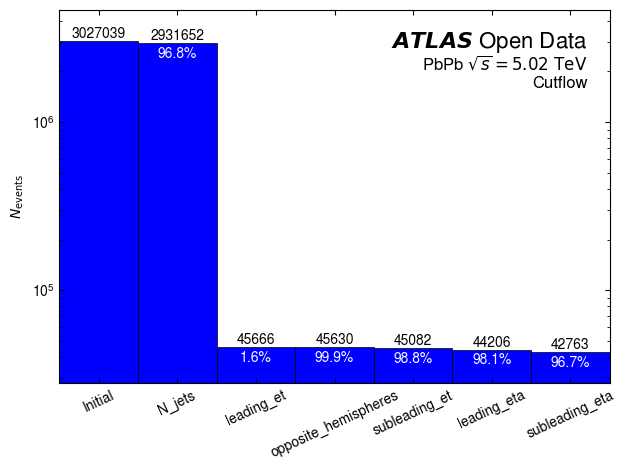

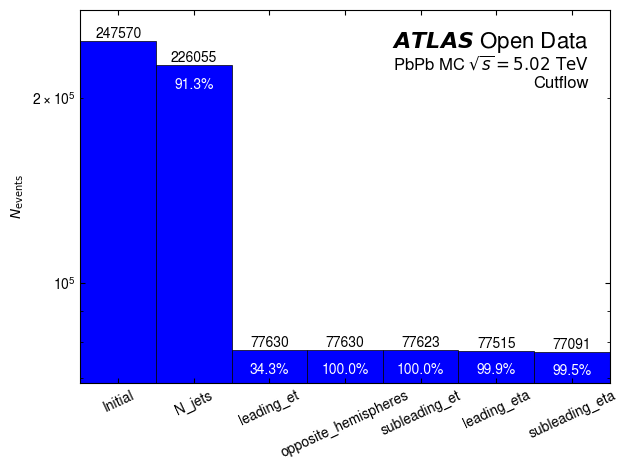

In [17]:
_ = plot_cutflow(cf_data)
_ = plot_cutflow(cf_mc,mc=True)

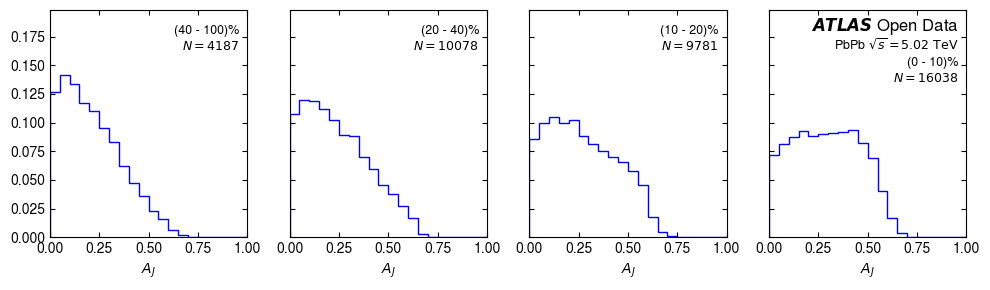

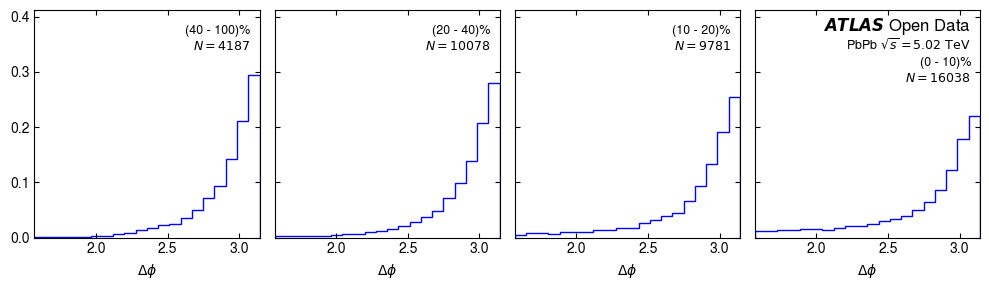

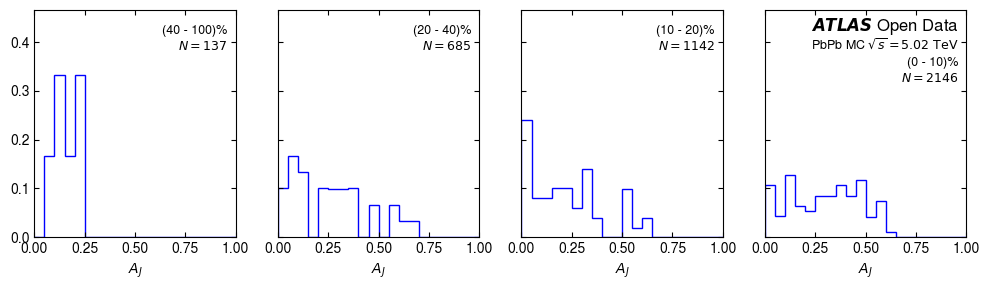

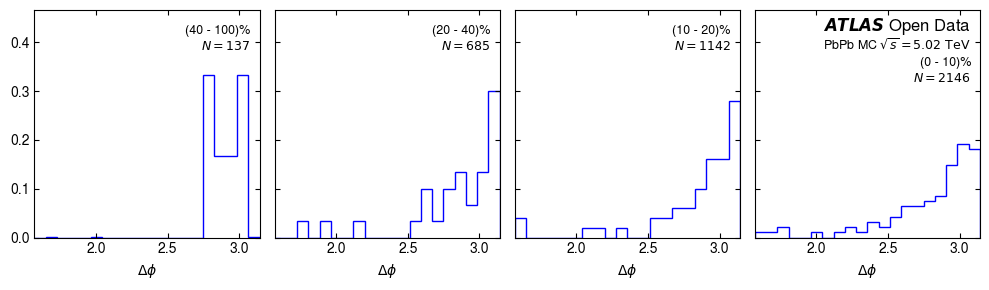

In [18]:
_ = plot_from_dict(AJ_data,label=r"$A_J$")
_ = plot_from_dict(PHI_data,label=r"$\Delta\phi$")
_ = plot_from_dict(AJ_mc,mc=True,label=r"$A_J$")
_ = plot_from_dict(PHI_mc,mc=True,label=r"$\Delta\phi$")

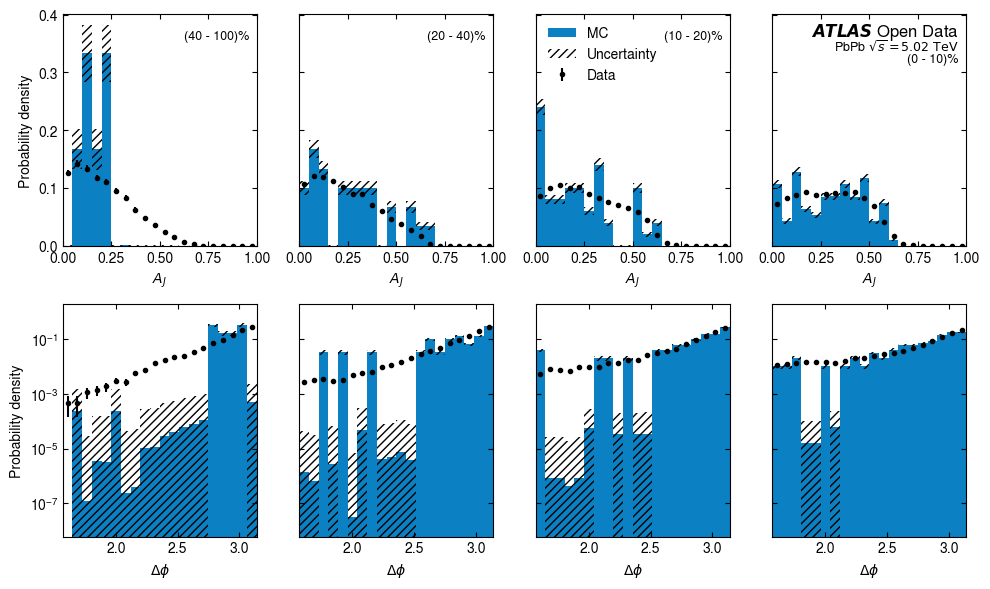

In [19]:
_ = plot_aj_phi_data_mc_comparison(AJ_data, AJ_mc, PHI_data, PHI_mc)
_.savefig("example_plot.pdf")

# TESTING
To be removed with release

In [20]:
f_data, f_mc = l_data[0], l_mc[0]


In [21]:
jets_data,_ = read_jets_fcal(f_data)
jets_mc,_ = read_jets_fcal(f_mc)

In [22]:
def get_mcweight(path):
    dsid = path.split("/")[-2]
    print(dsid)
    md = mc_metadata[dsid]
    print(md)

def get_luminosity_normalisation(path):
    dsid = path.split("/")[-2]
    md = mc_metadata[dsid]
    xsection, feff, sow = (md[x] for x in ("cross_section","filt_eff","n_gen"))
    Leff = sow / (xsection * feff)
    return 1/Leff
    

In [23]:
get_luminosity_normalisation(f_mc)

22.821749015435465

In [24]:
print(uproot.__version__)

5.6.9
